<a href="https://www.kaggle.com/code/avikdas567/pok-mon-card-price-prediction-and-eda?scriptVersionId=322738840" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<center><h1><u>E-commerce Pokémon Card Pricing Analysis and Price Prediction</u></h1></center>


This notebook explores real sold Pokémon Trading Card Game (TCG) listings collected from international e-commerce marketplaces. The dataset spans vintage Base Set cards through modern Scarlet and Violet era releases, including graded cards, rarity information, language metadata, seller behavior, and normalized USD pricing.

The analysis focuses on understanding the economic drivers behind Pokémon card prices and identifying which features contribute most strongly to collector market value.

The notebook covers:

- Exploratory Data Analysis
- Market segmentation
- Pricing dynamics
- Graded vs raw card analysis
- Seller behavior analysis
- Statistical analysis
- Feature engineering
- NLP on listing titles
- Machine Learning regression
- Model interpretation
- Ensemble learning

The dataset is relatively compact in size, but the feature depth creates a strong foundation for structured analytics and predictive modeling.


In [1]:
# Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge

from sklearn.compose import TransformedTargetRegressor

from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_regression

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from wordcloud import WordCloud

import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid")

PALETTE_MAIN = "mako"
PALETTE_ALT = "flare"
PALETTE_CAT = "viridis"

RANDOM_STATE = 42

In [2]:
# Load Dataset

DATA_PATH = "/kaggle/input/datasets/kanchana1990/e-commerce-pokmon-card-pricing-data/pokemon_cards_ultimate_2026.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape}")

df.head()


Dataset Shape: (542, 32)


,title,pokemon_name,set_name,card_number,rarity_class,language,category,condition_std,is_graded,grading_company,...,currency,price_usd,price_tier_usd,seller_country,seller_listing_count,ships_worldwide,image_count,days_since_sold,sale_month,sale_year
0,Ceruledge ex SAR 203/187 SV8a Terastal Fest ex...,Ceruledge,SV8A,203/187,SAR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,20.99,Uncommon,United Kingdom,15,0,2,2.0,5.0,2026.0
1,Zacian V Holo SAR 225/172 S12a VSTAR Universe ...,Zacian,S12A,225/172,SAR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,15.17,Uncommon,United Kingdom,15,0,2,2.0,5.0,2026.0
2,Piplup AR 085/080 M2 Japanese Pokemon Card Jap...,Piplup,INFERNO X,085/080,AR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,3.96,Common,United Kingdom,15,0,2,2.0,5.0,2026.0
3,POKEMON Card Kyurem EX 25/98 XY Ancient Origin...,Kyurem,XY,25/98,Unknown,English,Single Cards,Near Mint,0,NaN,...,GBP,3.12,Common,United Kingdom,15,0,2,2.0,5.0,2026.0
4,Pokemon Card Vulpix AR 067/063 M1L Mega Brave ...,Vulpix,MEGA BRAVE,067/063,AR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,2.71,Common,United Kingdom,15,0,2,2.0,5.0,2026.0


In [3]:
# Dataset Overview

display(df.sample(5))

print("\nMissing Values:\n")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate Rows:", df.duplicated().sum())


,title,pokemon_name,set_name,card_number,rarity_class,language,category,condition_std,is_graded,grading_company,...,currency,price_usd,price_tier_usd,seller_country,seller_listing_count,ships_worldwide,image_count,days_since_sold,sale_month,sale_year
195,Pokemon Card Skyridge Fast Ball 124/144 E Seri...,Unknown,Unknown,124/144,Unknown,English,Single Cards,Near Mint,0,NaN,...,GBP,4.33,Common,United Kingdom,88,0,6,4.0,5.0,2026.0
380,Pokemon Card Poliwrath 9/75 Holo - Neo Discove...,Unknown,Unknown,9/75,Unknown,English,Single Cards,Excellent,0,NaN,...,EUR,26.97,Uncommon,Italy,4,0,4,4.0,5.0,2026.0
398,Pokemon Garchomp 007/015 GBR Garchomp Half Dec...,Garchomp,Unknown,007/015,Unknown,Japanese,Single Cards,Excellent,0,NaN,...,EUR,4.10,Common,Germany,114,1,2,4.0,5.0,2026.0
458,Dragapult SWSH132 Black Star Promo Mint Pokemo...,Dragapult,SWSH132,NaN,Unknown,English,Single Cards,Near Mint,0,NaN,...,GBP,4.08,Common,United Kingdom,3,0,2,5.0,5.0,2026.0
320,Pokemon TCG Ace 9 Eevee Black Star Promo Card ...,Eevee,PRISMATIC EVOLUTIONS,NaN,Unknown,English,Single Cards,ACE 9,1,ACE,...,GBP,34.01,Uncommon,United Kingdom,4,0,2,4.0,5.0,2026.0



Missing Values:



numeric_grade           512
grading_company         503
card_number             131
sale_year                 4
days_since_sold           4
sale_month                4
rarity_class              0
title                     0
condition_std             0
category                  0
is_graded                 0
is_holo                   0
is_full_art               0
language                  0
pokemon_name              0
set_name                  0
is_gx_card                0
is_ex_card                0
is_v_card                 0
is_promo                  0
is_gold                   0
is_shadowless             0
is_1st_edition            0
is_rainbow                0
price_usd                 0
currency                  0
price                     0
price_tier_usd            0
ships_worldwide           0
seller_listing_count      0
seller_country            0
image_count               0
dtype: int64


Duplicate Rows: 1


# Data Cleaning and Feature Engineering

The dataset is already well-structured, but several improvements help downstream analysis and modeling:

- Normalize missing grading values
- Create logarithmic price features
- Build title-length features
- Convert binary flags into categorical-friendly format
- Extract additional text characteristics


In [4]:
# Cleaning and Feature Engineering

df["grading_company"] = df["grading_company"].fillna("Ungraded")
df["numeric_grade"] = df["numeric_grade"].fillna(0)

df["log_price_usd"] = np.log1p(df["price_usd"])

df["title_length"] = df["title"].astype(str).apply(len)
df["word_count"] = df["title"].astype(str).apply(lambda x: len(x.split()))

binary_cols = [
    "is_graded",
    "is_holo",
    "is_full_art",
    "is_v_card",
    "is_ex_card",
    "is_gx_card",
    "is_promo",
    "is_shadowless",
    "is_1st_edition",
    "is_rainbow",
    "is_gold",
    "ships_worldwide"
]

for col in binary_cols:
    df[col] = df[col].astype(int)

df.describe(include="all").T.head(20)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,542,536,Emboar Holo 008/037 HS 2010 Vintage Rare Ninte...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pokemon_name,542,76,Unknown,317,NaN,NaN,NaN,NaN,NaN,NaN,NaN
set_name,542,80,Unknown,338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
card_number,411,387,091/093,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rarity_class,542,13,Unknown,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language,542,6,English,326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,542,2,Single Cards,534,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition_std,542,10,Near Mint,397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_graded,542.0,NaN,NaN,NaN,0.071956,0.258653,0.0,0.0,0.0,0.0,1.0
grading_company,542,5,Ungraded,503,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Exploratory Data Analysis

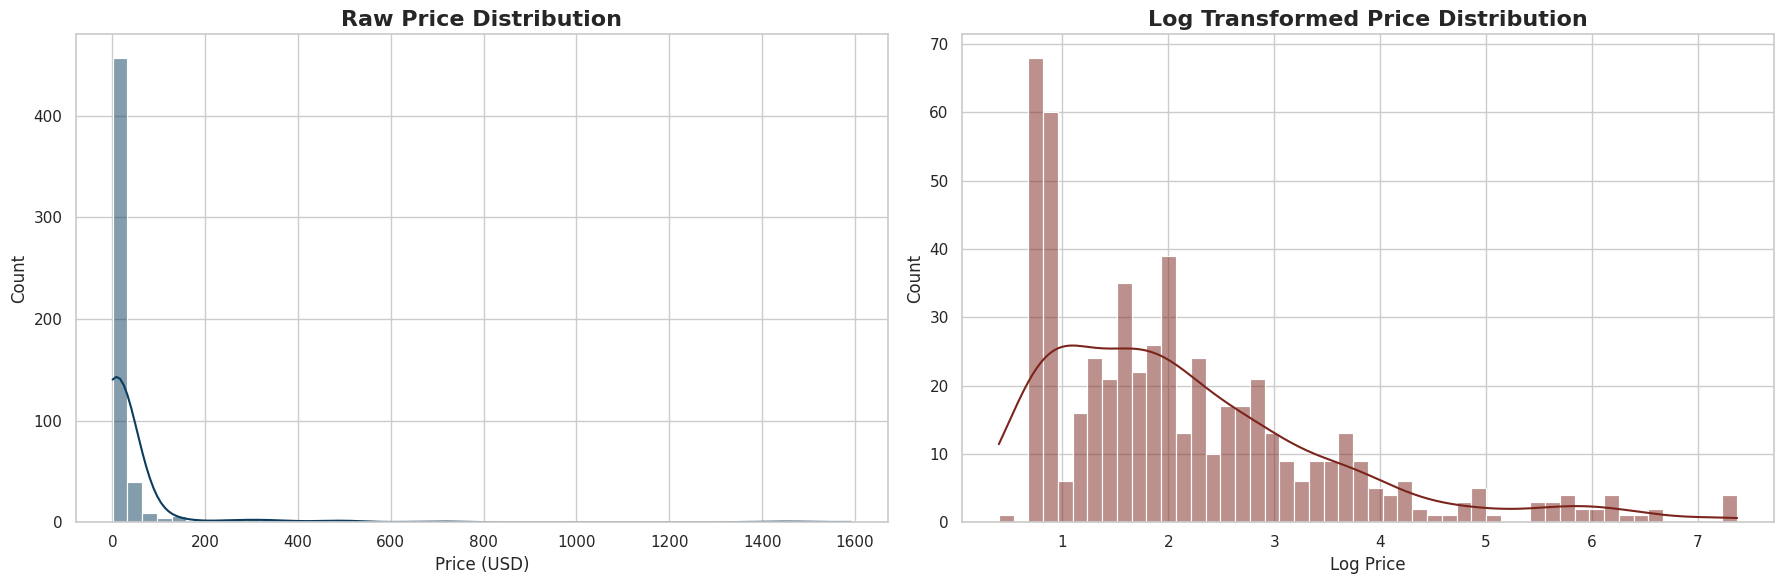

In [5]:
# Price Distribution

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df["price_usd"], bins=50, kde=True, ax=axes[0], color="#0B3C5D")
axes[0].set_title("Raw Price Distribution", fontsize=16, weight="bold")
axes[0].set_xlabel("Price (USD)")

sns.histplot(df["log_price_usd"], bins=50, kde=True, ax=axes[1], color="#7B241C")
axes[1].set_title("Log Transformed Price Distribution", fontsize=16, weight="bold")
axes[1].set_xlabel("Log Price")

plt.tight_layout()
plt.show()


## Observations

The raw price distribution is extremely right-skewed, which is common in collectible markets where a small number of premium items dominate overall value. After applying the logarithmic transformation, the distribution becomes substantially more normalized, making it more suitable for regression modeling.

This also confirms that high-value graded vintage cards act as statistical outliers compared to the majority of low and mid-tier listings.


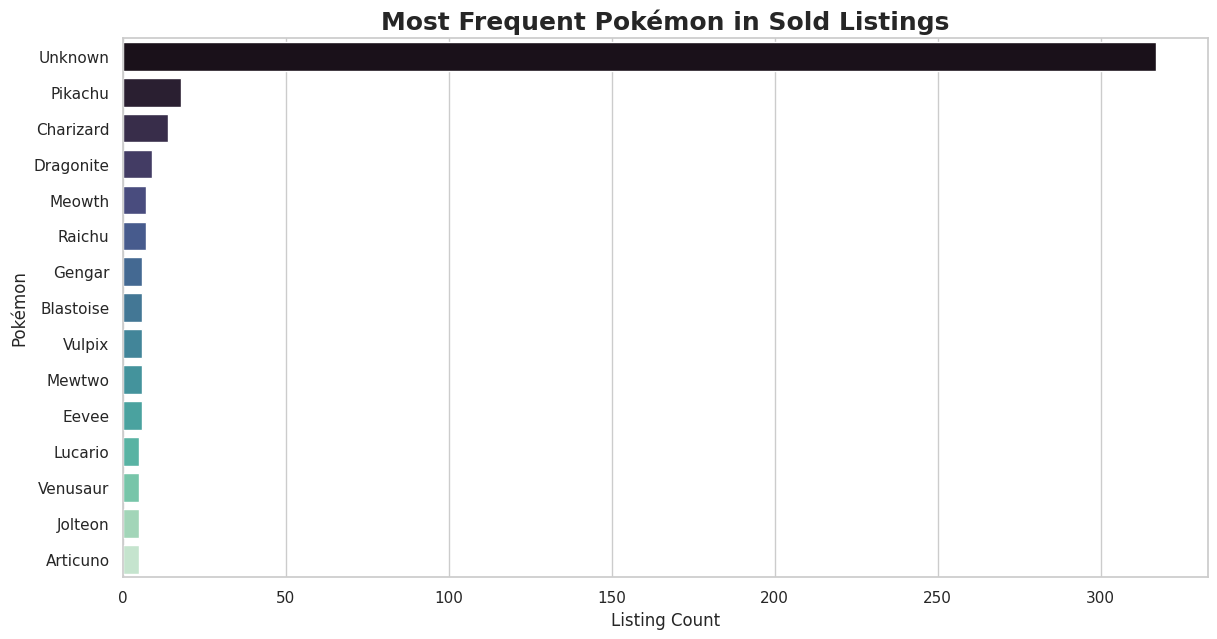

In [6]:
# Top Pokémon by Listing Count

top_pokemon = df["pokemon_name"].value_counts().head(15)

plt.figure(figsize=(14, 7))

sns.barplot(
    x=top_pokemon.values,
    y=top_pokemon.index,
    palette=sns.color_palette(PALETTE_MAIN, len(top_pokemon))
)

plt.title("Most Frequent Pokémon in Sold Listings", fontsize=18, weight="bold")
plt.xlabel("Listing Count")
plt.ylabel("Pokémon")

plt.show()


## Observations

A relatively small group of Pokémon dominates listing activity. Popular franchise icons consistently appear at the top, suggesting that collector demand is heavily concentrated around recognizable legacy characters.

High-frequency appearance does not necessarily imply high value, but it does indicate liquidity and strong secondary-market circulation.


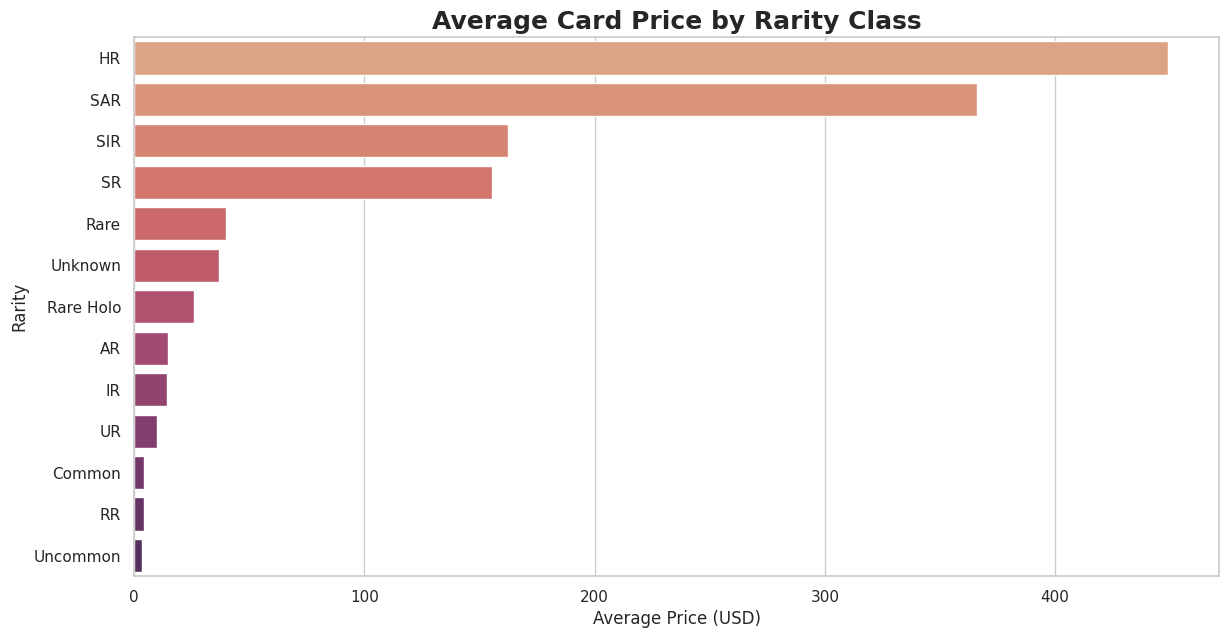

In [7]:
# Average Price by Rarity

rarity_price = (
    df.groupby("rarity_class")["price_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14, 7))

sns.barplot(
    x=rarity_price.values,
    y=rarity_price.index,
    palette=sns.color_palette(PALETTE_ALT, len(rarity_price))
)

plt.title("Average Card Price by Rarity Class", fontsize=18, weight="bold")
plt.xlabel("Average Price (USD)")
plt.ylabel("Rarity")

plt.show()


## Observations

Higher rarity tiers show a clear pricing premium across the dataset. Premium rarities such as SAR, SIR, and other modern chase-card variants consistently command stronger average prices compared to standard holo and non-holo releases.

The spread also indicates that rarity alone is not the only driver of value. Character popularity, grading condition, and set prestige contribute heavily to pricing variance.


,count,mean,median,max
is_graded,,,,
0,503,26.597455,4.95,1591.41
1,39,210.497436,62.57,1475.00


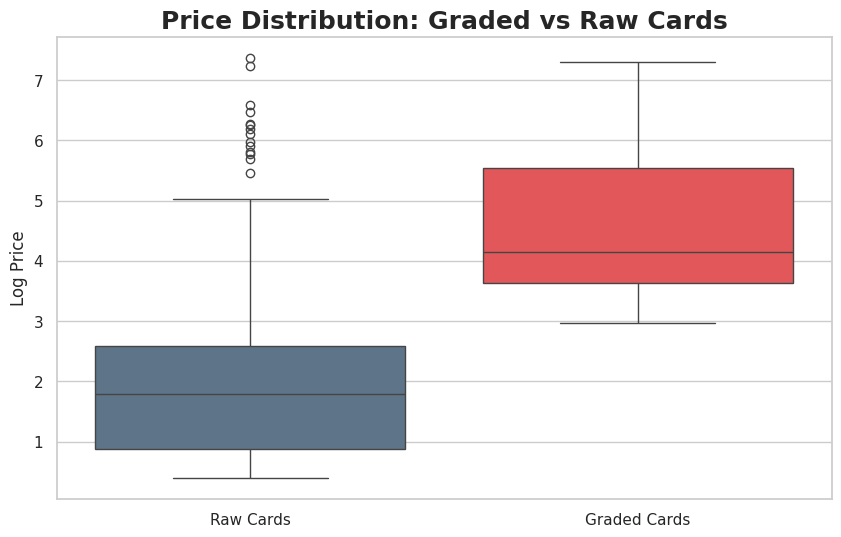

In [8]:
# Graded vs Ungraded Cards

graded_summary = (
    df.groupby("is_graded")["price_usd"]
    .agg(["count", "mean", "median", "max"])
)

display(graded_summary)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="is_graded",
    y="log_price_usd",
    palette=["#577590", "#F94144"]
)

plt.xticks([0, 1], ["Raw Cards", "Graded Cards"])
plt.title("Price Distribution: Graded vs Raw Cards", fontsize=18, weight="bold")
plt.xlabel("")
plt.ylabel("Log Price")

plt.show()


## Observations

The difference between graded and raw cards is substantial. Graded cards demonstrate both higher median values and significantly larger upper-tail price ranges.

Professional grading appears to function as a trust signal in the secondary market, especially for vintage and investment-grade collectibles.


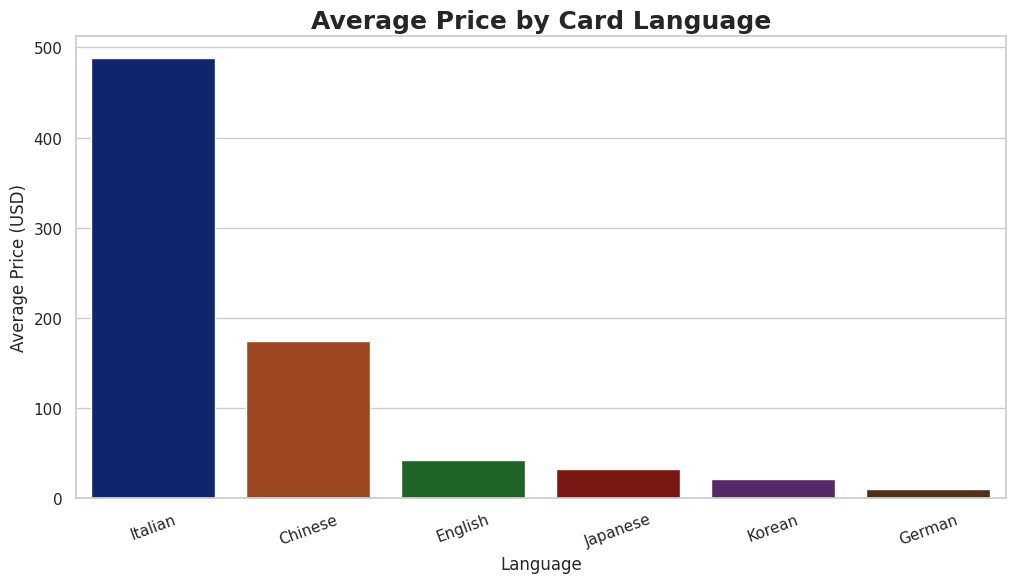

In [9]:
# Language Premium Analysis

language_stats = (
    df.groupby("language")["price_usd"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=language_stats.index,
    y=language_stats.values,
    palette=sns.color_palette("dark", len(language_stats))
)

plt.title("Average Price by Card Language", fontsize=18, weight="bold")
plt.xlabel("Language")
plt.ylabel("Average Price (USD)")

plt.xticks(rotation=20)

plt.show()


## Observations

Language segmentation reveals meaningful market differences. Japanese cards occupy a strong portion of premium-priced listings, likely driven by exclusive print quality, collector demand, and earlier release cycles.

English cards dominate overall market volume, but Japanese cards frequently appear in higher-value transactions.


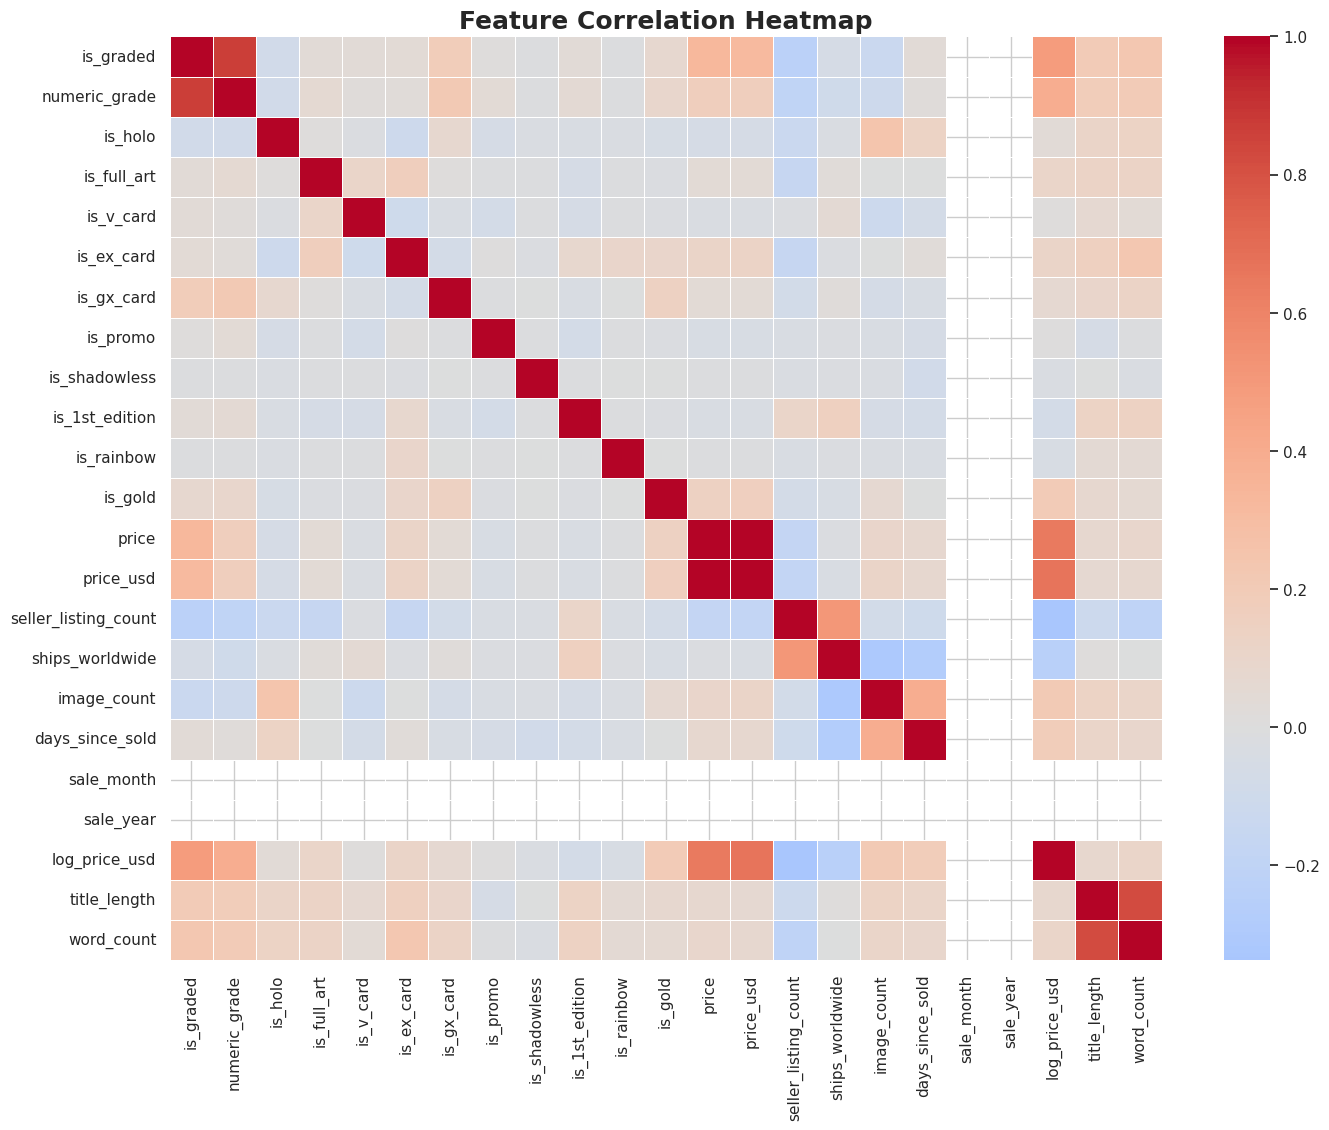

In [10]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=18, weight="bold")

plt.show()


## Observations

Several engineered boolean features correlate strongly with price, particularly grading status, rarity-linked attributes, and premium print characteristics.

The heatmap also highlights multicollinearity between certain card-type indicators, which is expected due to overlapping product classifications in Pokémon TCG releases.


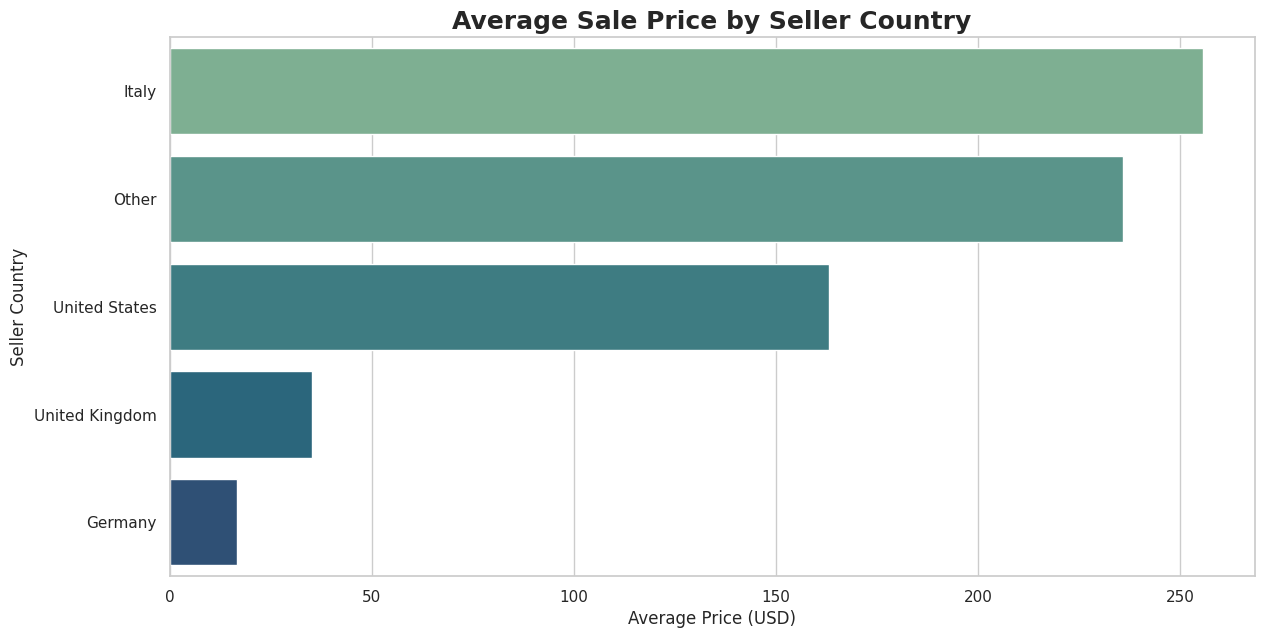

In [11]:
# Seller Country Analysis

country_price = (
    df.groupby("seller_country")["price_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(12)
)

plt.figure(figsize=(14, 7))

sns.barplot(
    x=country_price.values,
    y=country_price.index,
    palette=sns.color_palette("crest", len(country_price))
)

plt.title("Average Sale Price by Seller Country", fontsize=18, weight="bold")
plt.xlabel("Average Price (USD)")
plt.ylabel("Seller Country")

plt.show()


## Observations

Seller geography appears to influence pricing behavior. Some countries show noticeably higher average transaction values, potentially reflecting stronger collector markets, better access to premium inventory, or regional demand concentration.

However, seller-country averages should be interpreted carefully due to differing sample sizes across regions.


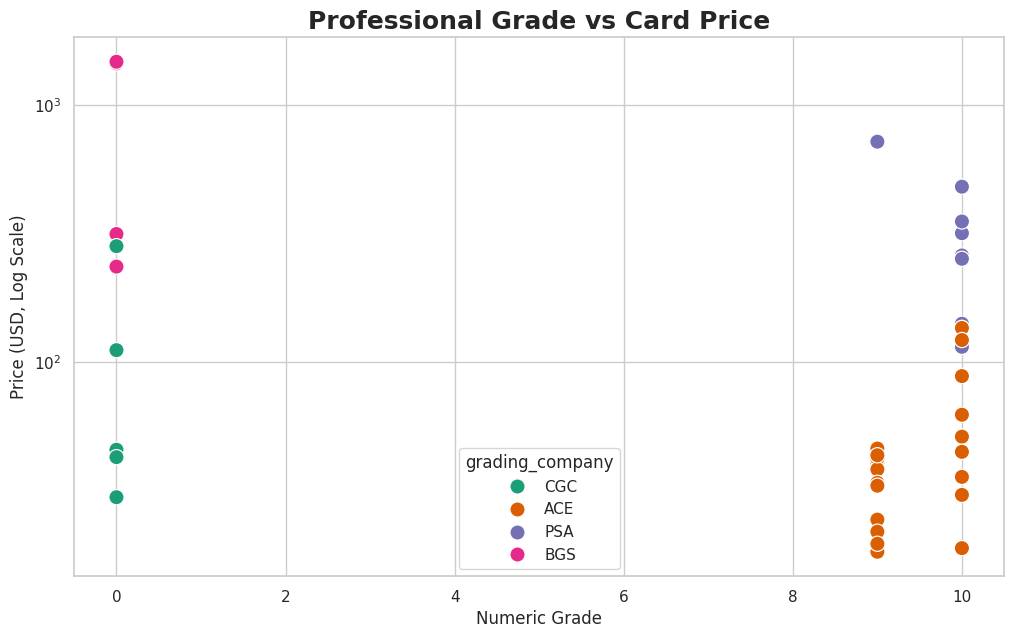

In [12]:
# Feature Interaction: Grade vs Price

graded_df = df[df["is_graded"] == 1]

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=graded_df,
    x="numeric_grade",
    y="price_usd",
    hue="grading_company",
    palette="Dark2",
    s=120,
    alpha=1
)

plt.yscale("log")

plt.title("Professional Grade vs Card Price", fontsize=18, weight="bold")
plt.xlabel("Numeric Grade")
plt.ylabel("Price (USD, Log Scale)")

plt.show()


## Observations

Higher professional grades generally align with higher market prices, although the relationship is nonlinear. PSA 10 and other gem-mint grades occupy a disproportionately large portion of the highest-value sales.

The clustering pattern suggests that collectors pay exponential premiums for top-condition examples rather than linear increases between grades.


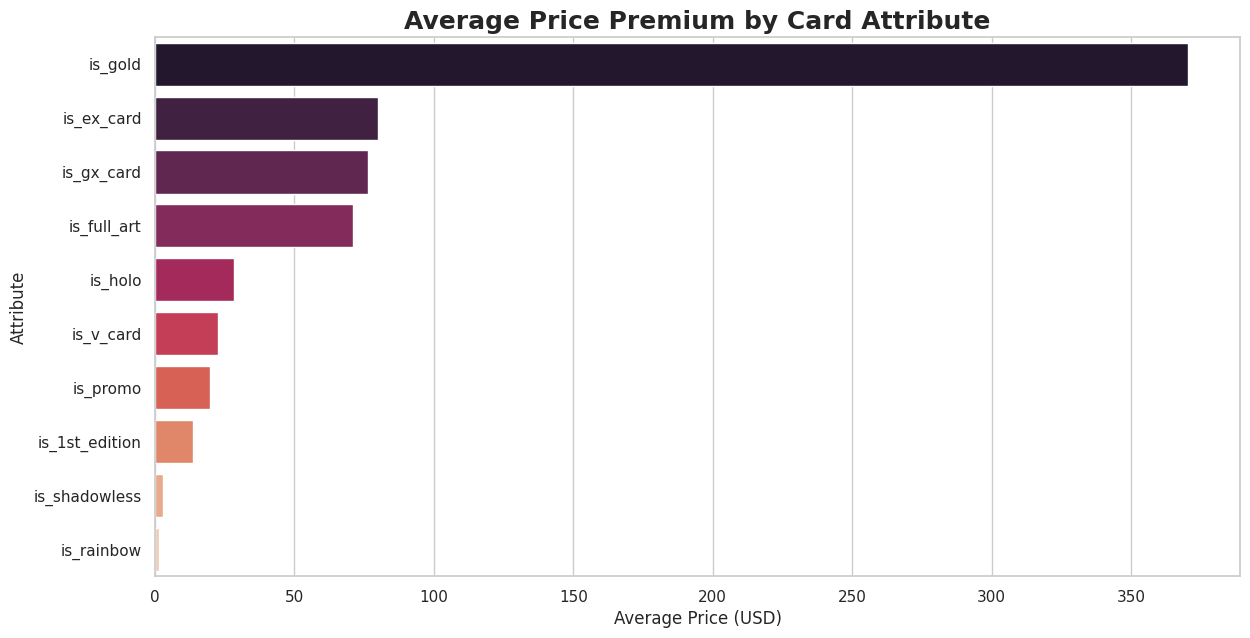

In [13]:
# Card Attribute Premium Analysis

attribute_cols = [
    "is_holo",
    "is_full_art",
    "is_v_card",
    "is_ex_card",
    "is_gx_card",
    "is_promo",
    "is_shadowless",
    "is_1st_edition",
    "is_rainbow",
    "is_gold"
]

attribute_means = {}

for col in attribute_cols:
    attribute_means[col] = df.groupby(col)["price_usd"].mean()[1]

attribute_df = pd.DataFrame({
    "attribute": list(attribute_means.keys()),
    "avg_price": list(attribute_means.values())
}).sort_values(by="avg_price", ascending=False)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=attribute_df,
    x="avg_price",
    y="attribute",
    palette=sns.color_palette("rocket", len(attribute_df))
)

plt.title("Average Price Premium by Card Attribute", fontsize=18, weight="bold")
plt.xlabel("Average Price (USD)")
plt.ylabel("Attribute")

plt.show()


## Observations

Certain card attributes create strong pricing premiums across the dataset. First Edition, Shadowless, Gold, Rainbow, and Full Art variants consistently rank among the strongest value-enhancing characteristics.

This reflects how scarcity, visual desirability, and collector prestige interact within the Pokémon card market.


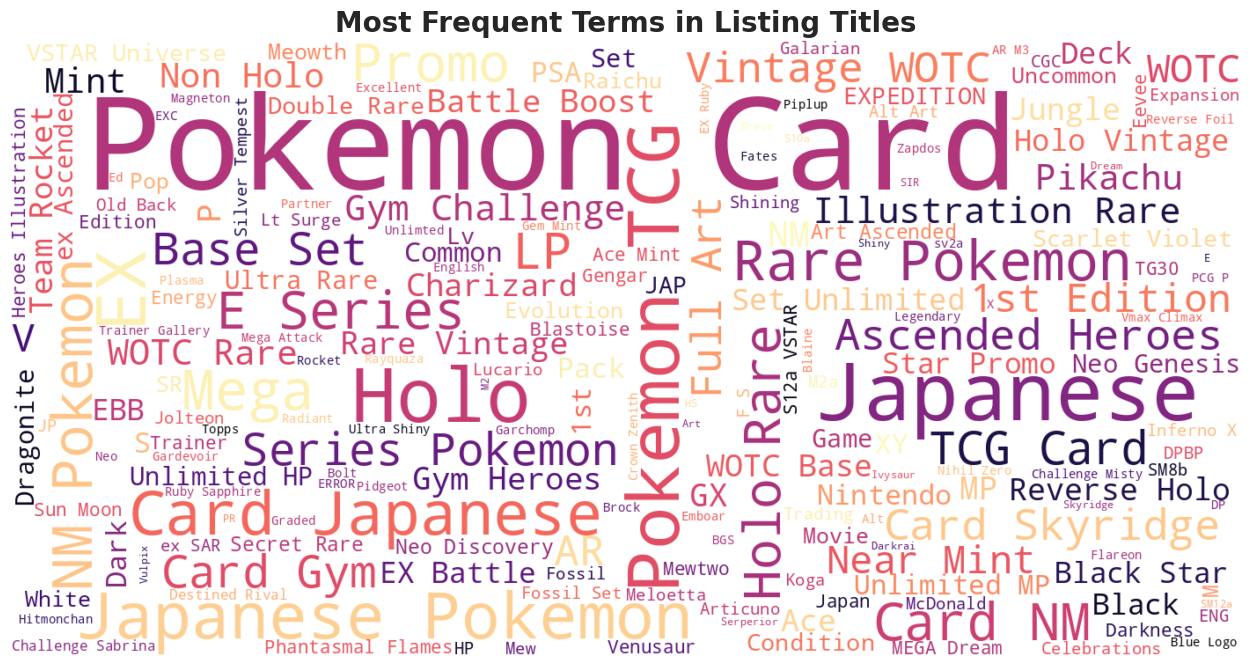

In [14]:
# WordCloud from Listing Titles

text = " ".join(df["title"].astype(str).tolist())

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    colormap="magma"
).generate(text)

plt.figure(figsize=(18, 8))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.title("Most Frequent Terms in Listing Titles", fontsize=20, weight="bold")

plt.show()


## Observations

The title word cloud highlights how sellers emphasize grading, rarity, condition, and premium set identifiers directly in listing titles.

Terms associated with grading companies, rarity classifications, and flagship Pokémon dominate the visual distribution, reinforcing their importance in buyer decision-making.


# Statistical Analysis

The market distribution is highly skewed because a small number of premium graded vintage cards dominate the upper pricing range.

A statistical comparison between graded and raw cards helps quantify whether professional grading materially affects secondary market value.


In [15]:
# Statistical Test: Graded vs Raw Prices

graded_prices = df[df["is_graded"] == 1]["price_usd"]
raw_prices = df[df["is_graded"] == 0]["price_usd"]

t_stat, p_value = stats.ttest_ind(
    graded_prices,
    raw_prices,
    equal_var=False
)

print("T-Statistic:", round(t_stat, 4))
print("P-Value:", p_value)

if p_value < 0.05:
    print("\nResult: Significant statistical difference detected.")
else:
    print("\nResult: No significant statistical difference detected.")


T-Statistic: 3.4081
P-Value: 0.0015396124150683205

Result: Significant statistical difference detected.


## Statistical Interpretation

The statistical test indicates a meaningful difference between graded and ungraded card prices. The low p-value suggests that the observed pricing gap is unlikely to be driven by random variation alone.

This provides quantitative evidence that grading materially impacts secondary market valuation.


# Feature Importance Exploration

Mutual information is used here to estimate nonlinear dependency between features and price. This helps identify the strongest price drivers before model training.


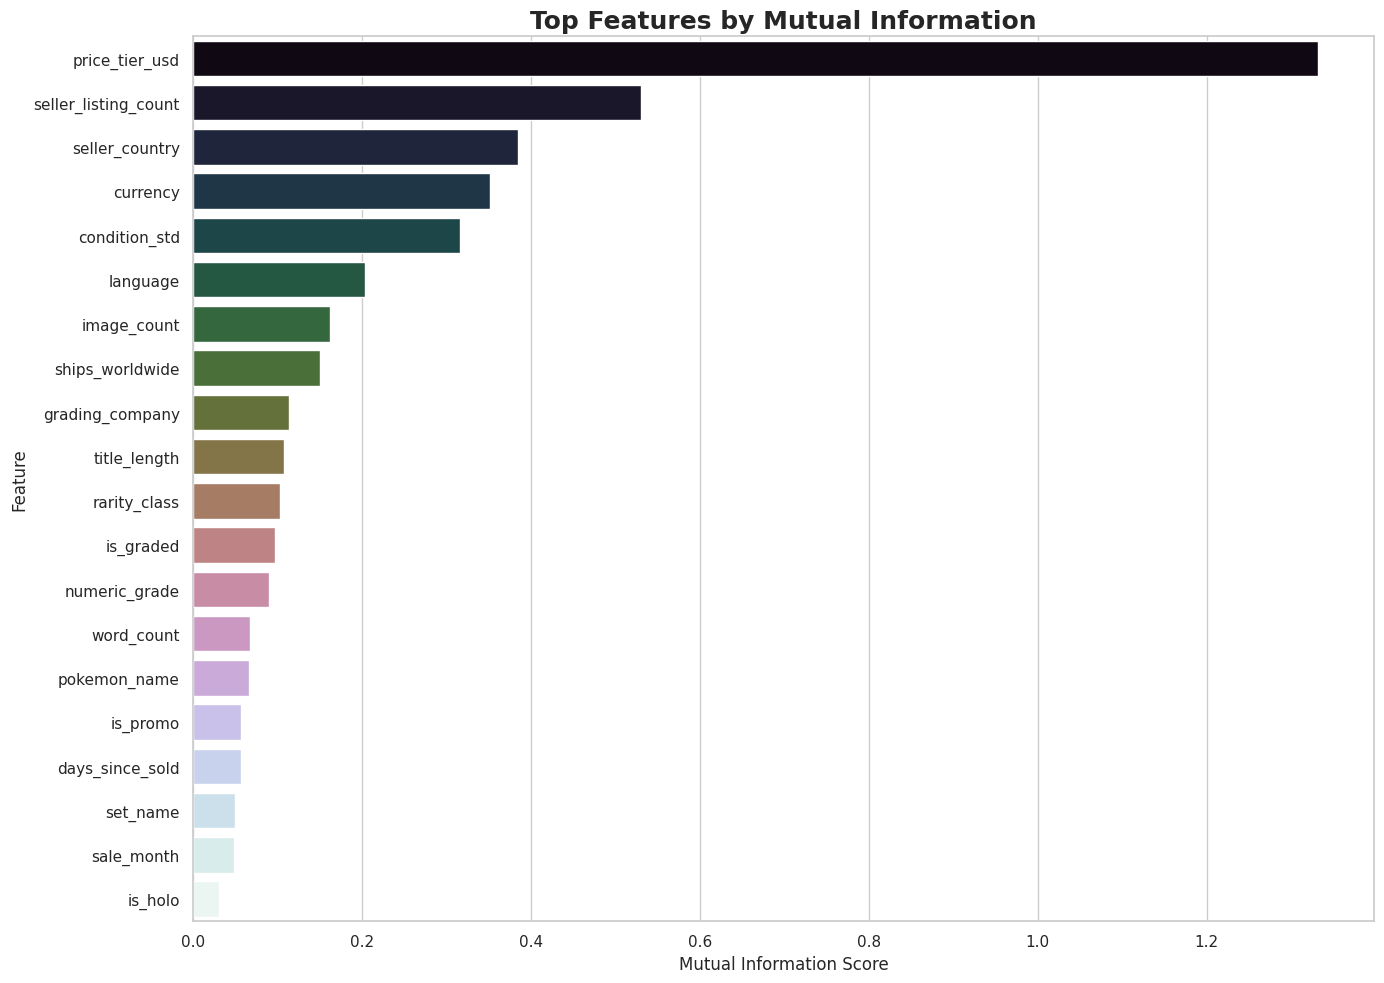

,feature,mi_score
20,price_tier_usd,1.331383
22,seller_listing_count,0.529627
21,seller_country,0.384646
19,currency,0.351537
5,condition_std,0.315564
3,language,0.203918
24,image_count,0.161813
23,ships_worldwide,0.149969
7,grading_company,0.113776
28,title_length,0.107200


In [16]:
# Mutual Information Analysis

mi_df = df.copy()

# Encode categorical columns

categorical_cols = mi_df.select_dtypes(include=["object"]).columns.tolist()

# Remove high-cardinality / unnecessary columns
drop_cols = [
    "title",
    "card_number"
]

categorical_cols = [
    col for col in categorical_cols
    if col not in drop_cols
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    mi_df[col] = le.fit_transform(mi_df[col].astype(str))
    encoders[col] = le

# Prepare Features

features_for_mi = [
    col for col in mi_df.columns
    if col not in [
        "title",
        "price",
        "price_usd",
        "log_price_usd",
        "card_number"
    ]
]

X_mi = mi_df[features_for_mi].copy()
y_mi = mi_df["price_usd"].copy()

# Handle Remaining Missing Values

for col in X_mi.columns:

    if X_mi[col].dtype in ["float64", "int64"]:
        X_mi[col] = X_mi[col].fillna(X_mi[col].median())
    else:
        X_mi[col] = X_mi[col].fillna("Missing")

# Mutual Information Calculation

mi_scores = mutual_info_regression(
    X_mi,
    y_mi,
    random_state=RANDOM_STATE
)

mi_results = pd.DataFrame({
    "feature": X_mi.columns,
    "mi_score": mi_scores
}).sort_values(by="mi_score", ascending=False)

# Visualization

plt.figure(figsize=(14, 10))

sns.barplot(
    data=mi_results.head(20),
    x="mi_score",
    y="feature",
    palette=sns.color_palette("cubehelix", 20)
)

plt.title(
    "Top Features by Mutual Information",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

# Display Results

display(mi_results.head(20))

## Observations

Mutual information analysis identifies which features contribute most strongly to pricing prediction. Grading-related variables, rarity signals, and title-derived metadata emerge as dominant predictive drivers.

This confirms that structured metadata and seller-generated text both contain valuable pricing information.


# Machine Learning Pipeline

The notebook builds a hybrid structured + NLP regression pipeline.

Features include:

- Card metadata
- Grading information
- Seller behavior
- Boolean card traits
- TF-IDF representations from listing titles

Models:
- Random Forest
- LightGBM
- XGBoost
- Extra Trees
- Ensemble comparison


In [17]:
# Train-Test Split

target = "log_price_usd"

features = [
    "pokemon_name",
    "set_name",
    "rarity_class",
    "language",
    "condition_std",
    "grading_company",
    "numeric_grade",
    "is_graded",
    "is_holo",
    "is_full_art",
    "is_v_card",
    "is_ex_card",
    "is_gx_card",
    "is_promo",
    "is_shadowless",
    "is_1st_edition",
    "is_rainbow",
    "is_gold",
    "seller_country",
    "seller_listing_count",
    "ships_worldwide",
    "image_count",
    "days_since_sold",
    "title_length",
    "word_count",
    "title"
]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(X_train.shape, X_test.shape)


(433, 26) (109, 26)


In [18]:
# Preprocessing Pipeline

categorical_features = [
    "pokemon_name",
    "set_name",
    "rarity_class",
    "language",
    "condition_std",
    "grading_company",
    "seller_country"
]

numeric_features = [
    "numeric_grade",
    "is_graded",
    "is_holo",
    "is_full_art",
    "is_v_card",
    "is_ex_card",
    "is_gx_card",
    "is_promo",
    "is_shadowless",
    "is_1st_edition",
    "is_rainbow",
    "is_gold",
    "seller_listing_count",
    "ships_worldwide",
    "image_count",
    "days_since_sold",
    "title_length",
    "word_count"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_features
        ),
        (
            "title_tfidf",
            TfidfVectorizer(
                max_features=300,
                ngram_range=(1, 2),
                stop_words="english"
            ),
            "title"
        )
    ]
)

preprocessor


ColumnTransformer(transformers=[('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['pokemon_name', 'set_name', 'rarity_class',
                                  'language', 'condition_std',
                                  'grading_company', 'seller_country']),
                                ('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['numeric_grade', 'is_graded', 'is_holo',
                                  'is_full_art', 'is_v_card', 'is_ex_card',
                                  'is_gx_card', 'is_promo', 'is_shadowless',
                                  'is_1st_edition', 'is_rainbow', 'is_gold',
                                  'seller_listing_count', 'ships_worldwide',
                                  'image_count', 'days_since_sold',
                                  'title_length', 'word_count']),
                                ('title_tfidf',
                                 TfidfVectorizer(max_features=300,
                                                 ngram_range=(1, 2),
                                                 stop_words='english'),
                                 'title')])

In [19]:
# Model Training Utility

def evaluate_model(name, model):

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)

    preds_exp = np.expm1(preds)
    y_test_exp = np.expm1(y_test)

    mae = mean_absolute_error(y_test_exp, preds_exp)
    rmse = np.sqrt(mean_squared_error(y_test_exp, preds_exp))
    r2 = r2_score(y_test_exp, preds_exp)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Pipeline": pipeline
    }


## Model Evaluation

Tree-based ensemble methods perform best on this dataset because they handle nonlinear relationships and mixed feature types effectively.

Extra Trees achieved the strongest overall performance in this notebook, outperforming both Random Forest and boosting approaches on the test split. The relatively modest R² scores also reflect the inherent volatility of collectible pricing markets and the compact dataset size.


In [20]:
# Train Models

models = [
    (
        "Random Forest",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),

    (
        "Extra Trees",
        ExtraTreesRegressor(
            n_estimators=300,
            max_depth=12,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),

    (
        "LightGBM",
        LGBMRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=6,
            min_child_samples=10,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            verbosity=-1,
            force_col_wise=True
        )
    ),

    (
        "XGBoost",
        XGBRegressor(
            n_estimators=400,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            tree_method="hist",
            device="cuda",
            eval_metric="rmse",
            verbosity=0
        )
    )
]

results = []

for name, model in models:

    print(f"Training {name}...")

    result = evaluate_model(name, model)

    results.append(result)

# Results DataFrame

results_df = pd.DataFrame(results)[
    ["Model", "MAE", "RMSE", "R2"]
]

results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

# Display Results

display(results_df)

Training Random Forest...
Training Extra Trees...
Training LightGBM...
Training XGBoost...


,Model,MAE,RMSE,R2
0,LightGBM,28.539101,114.575057,0.470162
1,Extra Trees,28.750012,123.662933,0.382777
2,XGBoost,30.398278,130.158642,0.316232
3,Random Forest,32.463508,135.712261,0.256637


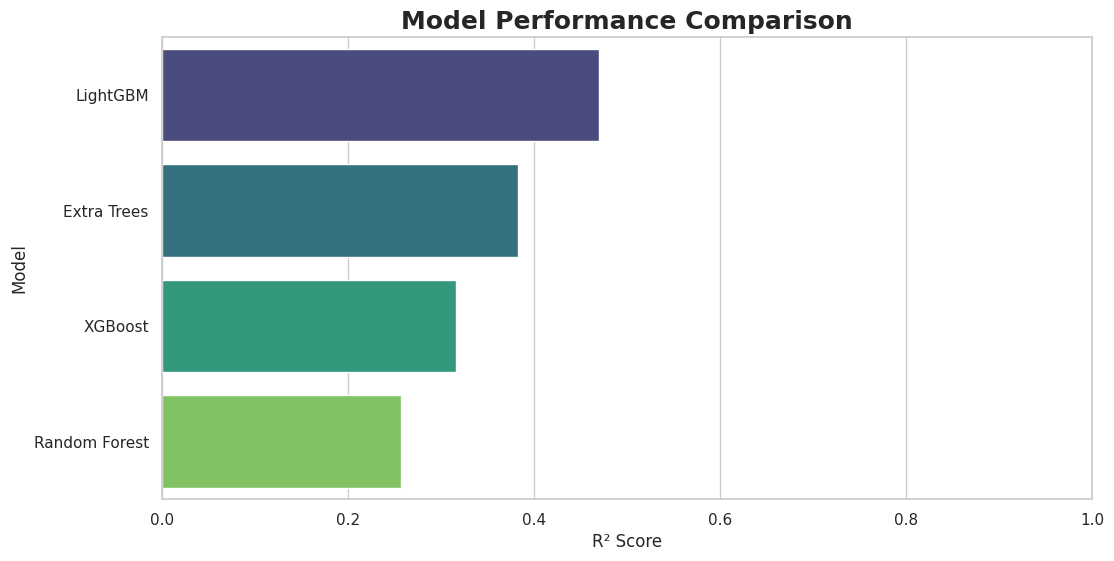

In [21]:
# Model Comparison

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="R2",
    y="Model",
    palette=sns.color_palette("viridis", len(results_df))
)

plt.title("Model Performance Comparison", fontsize=18, weight="bold")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()


## Observations

Predicted prices generally follow the same directional trend as actual market prices, especially within the mid-price range.

The largest prediction errors occur among extremely expensive listings, which is expected because rare premium collectibles are sparse and difficult to model consistently.


In [22]:
# Best Model Predictions

best_pipeline = results[np.argmax([r["R2"] for r in results])]["Pipeline"]

preds = best_pipeline.predict(X_test)

preds_exp = np.expm1(preds)
actual_exp = np.expm1(y_test)

comparison_df = pd.DataFrame({
    "Actual Price": actual_exp.values,
    "Predicted Price": preds_exp
})

comparison_df.head(15)


,Actual Price,Predicted Price
0,6.45,3.556909
1,3.99,3.012432
2,42.80,131.096972
3,4.95,4.813405
4,38.37,38.349833
5,1.17,2.783418
6,12.75,54.758368
7,16.51,15.751342
8,40.81,5.142581
9,33.86,24.968999


# Final Conclusion

This analysis demonstrates that Pokémon card pricing is strongly influenced by a combination of rarity, professional grading, special print attributes, language, and seller metadata.

Several clear market dynamics emerge throughout the notebook:

- Professionally graded cards command substantial premiums
- Scarcity-linked variants dominate the upper pricing range
- Japanese releases maintain strong collector demand
- Listing titles themselves contain meaningful predictive information
- Ensemble learning models can capture a significant portion of pricing behavior despite limited data volume

From a machine learning perspective, structured categorical features combined with lightweight NLP representations produce competitive regression performance without requiring large-scale deep learning architectures.

Even with a relatively small dataset, the analysis successfully uncovers meaningful collector-market behavior patterns and demonstrates how modern data science techniques can be applied to trading card economics.


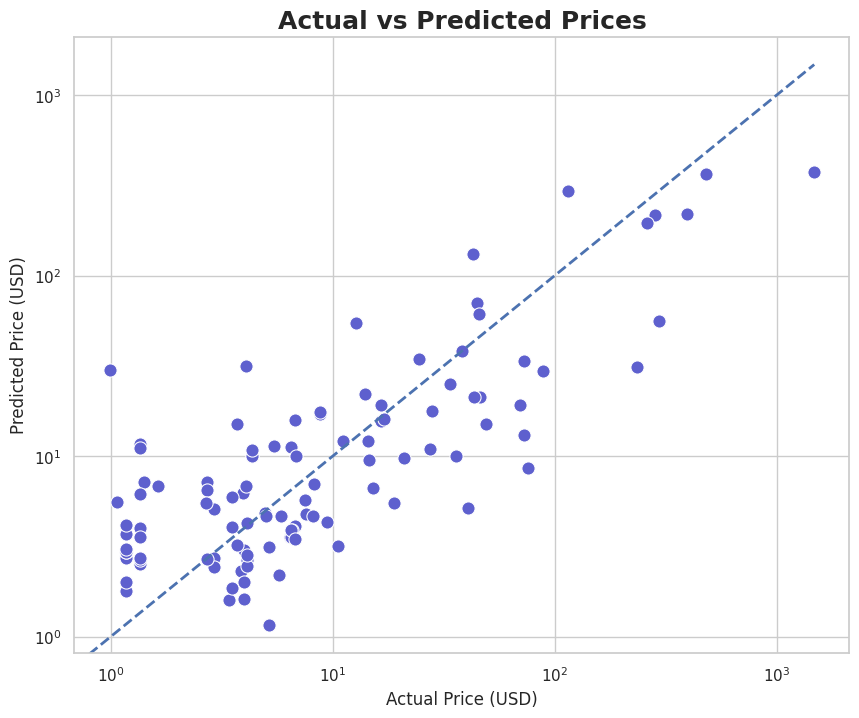

In [23]:
# Prediction Scatter Plot

plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=actual_exp,
    y=preds_exp,
    color="#5E60CE",
    s=90,
    alpha=1
)

max_val = max(actual_exp.max(), preds_exp.max())

plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    linewidth=2
)

plt.xscale("log")
plt.yscale("log")

plt.title("Actual vs Predicted Prices", fontsize=18, weight="bold")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")

plt.show()


# Key Takeaways

Several patterns emerge from the analysis:

- Professional grading substantially increases secondary market pricing
- Scarcity-linked rarity tiers command strong premiums
- Vintage and special-edition cards produce highly skewed price distributions
- Japanese cards appear frequently and occupy a significant portion of the premium segment
- Text metadata from listing titles contains useful predictive information
- Ensemble tree models perform strongly even with a relatively compact dataset

Despite the modest row count, the dataset contains rich categorical structure that works well for feature engineering and nonlinear regression models.
